# Paper 1 — SMA-CLMPNet: measured results

Open from **Anaconda Navigator → Jupyter Notebook**, then choose the kernel
**Python (VideoForgeryCPU)** (Kernel ▸ Change kernel). Run all cells with
*Cell ▸ Run All*; each stage prints a progress bar as it works.

Everything below is read from stored run artefacts — `Analysis1/TRUE`,
`Analysis1/TRUE_KF` and the JSON files in `Optimized/`. No model is trained
here and no number is typed by hand.

> **Scoring.** All metrics come from `Optimized/metrics_fixed.py`, which builds
> the confusion matrix with scikit-learn. The vendored `mealpy/metrics.py` in
> this repository rewrites predictions toward the labels before scoring; every
> number it produced has been removed. Do not import it.

> **Reading the tables.** The corpus is 29 authentic / 21 forged, so a model
> that answers *authentic* for every input scores 58 % accuracy and F1 > 73.
> Only **recall on forged** (specificity) exposes that. It is reported beside
> every other metric for exactly this reason.

## 1. Environment and data

In [1]:
import os, sys, json, time
from pathlib import Path

PROJECT = Path.cwd()
if not (PROJECT / "Optimized").exists():
    PROJECT = PROJECT.parent
sys.path.insert(0, str(PROJECT / "Optimized"))
os.chdir(PROJECT)

# scipy/skimage hard-crash on this machine unless the env's Library\bin is on
# PATH (DLL delay-load 0xc06d007f), so put it there before anything imports.
env = Path(sys.executable).parent
os.environ["PATH"] = os.pathsep.join(
    [str(env), str(env / "Library" / "bin"), str(env / "Scripts"),
     os.environ.get("PATH", "")])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

print(f"python   {sys.version.split()[0]}")
print(f"env      {env}")
print(f"project  {PROJECT}")
print(f"numpy    {np.__version__}")
print(f"pandas   {pd.__version__}")

python   3.8.20
env      C:\Users\USER\anaconda3\envs\VideoForgeryCPU
project  C:\Users\USER\Downloads\PostDoc\Implimentation_Paper1
numpy    1.21.6
pandas   1.3.4


In [2]:
from article_data import (ACC, BAL, F1, ORDER, PRE, SEN, SPE, GROUP,
                          load, majority_accuracy, degenerate, pretty)

D = load()
print(f"corpus            {D['audit']['n']} videos, "
      f"{D['audit']['authentic']} authentic / {D['audit']['forged']} forged")
print(f"models            {len(ORDER)}")
print(f"training %        {D['pcts']}")
print(f"k values measured {D['ks']}")
print(f"constant-'authentic' baseline: {majority_accuracy(D):.2f}% accuracy")

corpus            50 videos, 29 authentic / 21 forged
models            12
training %        [40, 50, 60, 70, 80, 90]
k values measured [6, 7, 8, 9]
constant-'authentic' baseline: 58.00% accuracy


## 2. Metric tables — accuracy, precision, recall, F1

One row per model. `Recall (auth.)` is recall of the authentic class,
`Recall (forged)` of the forged class; the released code treats class 0
(authentic) as positive, so its *sensitivity* is the first and its
*specificity* the second.

In [3]:
def metric_table(key, label):
    rows = []
    for m in ORDER:
        a = D[key][m]
        rows.append({
            "Model": pretty(m),
            "Group": GROUP[m],
            "Accuracy": np.nanmean(a[:, ACC]),
            "Precision": np.nanmean(a[:, PRE]),
            "Recall (auth.)": np.nanmean(a[:, SEN]),
            "Recall (forged)": np.nanmean(a[:, SPE]),
            "F1": np.nanmean(a[:, F1]),
            "Balanced acc.": np.nanmean(a[:, BAL]),
            "Degenerate": f"{degenerate(a)}/{a.shape[0]}",
        })
    df = (pd.DataFrame(rows)
            .sort_values("Balanced acc.", ascending=False)
            .reset_index(drop=True))
    print(f"\n{label}")
    return df.round(2)

sweep_tbl = metric_table("sweep", "Means over the training-percentage sweep")
sweep_tbl


Means over the training-percentage sweep


,Model,Group,Accuracy,Precision,Recall (auth.),Recall (forged),F1,Balanced acc.,Degenerate
0,MobileNetV3-Large,modern backbone,61.41,62.69,78.70,40.79,69.17,59.75,0/6
1,STIDNet,published cohort,61.52,60.65,93.52,19.54,72.89,56.53,3/6
2,EfficientNetV2-S,modern backbone,56.84,67.59,55.28,56.92,58.26,56.10,0/6
3,SMA-CLMPNet-Opt,proposed (tuned),54.51,63.49,82.41,21.43,61.07,51.92,4/6
4,ConvNeXt-Tiny,modern backbone,51.86,55.63,57.41,43.41,55.82,50.41,0/6
5,SMA-CLMPNet,proposed,53.53,55.49,83.33,16.67,59.44,50.00,6/6
6,MUSE-CLMPNet,ablation,55.62,55.62,100.00,0.00,71.44,50.00,6/6
7,EfficientNet,published cohort,52.93,55.13,83.33,16.67,59.19,50.00,6/6
8,GLCM,published cohort,48.46,54.62,57.41,39.65,49.38,48.53,2/6
9,SCAM-CLMPNet,ablation,47.22,57.72,51.11,44.68,44.35,47.89,2/6


In [4]:
kf_tbl = metric_table("kf", f"Means over k = {D['ks']}")
kf_tbl


Means over k = [6, 7, 8, 9]


,Model,Group,Accuracy,Precision,Recall (auth.),Recall (forged),F1,Balanced acc.,Degenerate
0,STIDNet,published cohort,78.27,82.50,78.75,77.08,80.42,77.92,0/4
1,GLCM,published cohort,73.66,69.49,100.00,39.58,81.57,69.79,1/4
2,EfficientNetV2-S,modern backbone,59.87,60.12,90.00,22.92,71.52,56.46,1/4
3,ConvNeXt-Tiny,modern backbone,53.52,56.67,75.42,25.00,64.52,50.21,0/4
4,SMA-CLMPNet,proposed,56.30,56.30,100.00,0.00,71.94,50.00,4/4
5,MUSE-CLMPNet,ablation,56.30,56.30,100.00,0.00,71.94,50.00,4/4
6,SMA-CLMPNet-Opt,proposed (tuned),53.52,56.55,75.00,25.00,54.08,50.00,4/4
7,DCNN,published cohort,56.30,56.30,100.00,0.00,71.94,50.00,4/4
8,EfficientNet,published cohort,56.30,56.30,100.00,0.00,71.94,50.00,4/4
9,SCAM-CLMPNet,ablation,40.48,37.50,30.00,60.42,25.00,45.21,1/4


### The F1 trap, made explicit

Below are the models whose recall on the forged class is exactly zero. They
catch no forgeries at all, and their accuracy, precision and F1 look
unremarkable.

In [5]:
bad = kf_tbl[kf_tbl["Recall (forged)"] == 0]
print(f"{len(bad)} of {len(ORDER)} models catch no forgeries under k-fold:")
bad[["Model", "Accuracy", "Precision", "Recall (auth.)",
     "Recall (forged)", "F1", "Balanced acc."]]

5 of 12 models catch no forgeries under k-fold:


,Model,Accuracy,Precision,Recall (auth.),Recall (forged),F1,Balanced acc.
4,SMA-CLMPNet,56.30,56.3,100.00,0.0,71.94,50.00
5,MUSE-CLMPNet,56.30,56.3,100.00,0.0,71.94,50.00
7,DCNN,56.30,56.3,100.00,0.0,71.94,50.00
8,EfficientNet,56.30,56.3,100.00,0.0,71.94,50.00
11,ResNet-RS-50,9.47,17.5,16.25,0.0,16.81,8.12


## 3. Generate every chart, with a progress bar

This is the same code that produces the figures in the paper, so what runs
here is what the manuscript embeds.

In [6]:
import importlib
import make_metric_charts as mmc
importlib.reload(mmc)

t0 = time.time()
mmc.main()
print(f"\ntotal {time.time() - t0:.1f}s")

reading measured results from Analysis1/ and Optimized/


  12 models · train% [40, 50, 60, 70, 80, 90] · k [6, 7, 8, 9]

generating charts


  [████████··································]  1/5   20.0%  eta  1.9s  fig14_metrics_sweep_grouped.png   

  [████████████████··························]  2/5   40.0%  eta  1.3s  fig15_metrics_kfold_grouped.png   

  [█████████████████████████·················]  3/5   60.0%  eta  1.1s  fig16_metric_panels_sweep.png     

  [█████████████████████████████████·········]  4/5   80.0%  eta  0.6s  fig17_metric_panels_kfold.png     

  [██████████████████████████████████████████]  5/5  100.0%  eta  0.0s  fig18_roc_and_operating_points.png

  [██████████████████████████████████████████] 5/5  100.0%  done in 2.8s                                  

wrote 5 charts to Results\Genuine
k-fold state at generation time: k = [6, 7, 8, 9]

total 2.9s


## 4. Bar charts — all models, all metrics

**fig14_metrics_sweep_grouped.png** — accuracy / precision / recall / F1 per model, training-percentage means

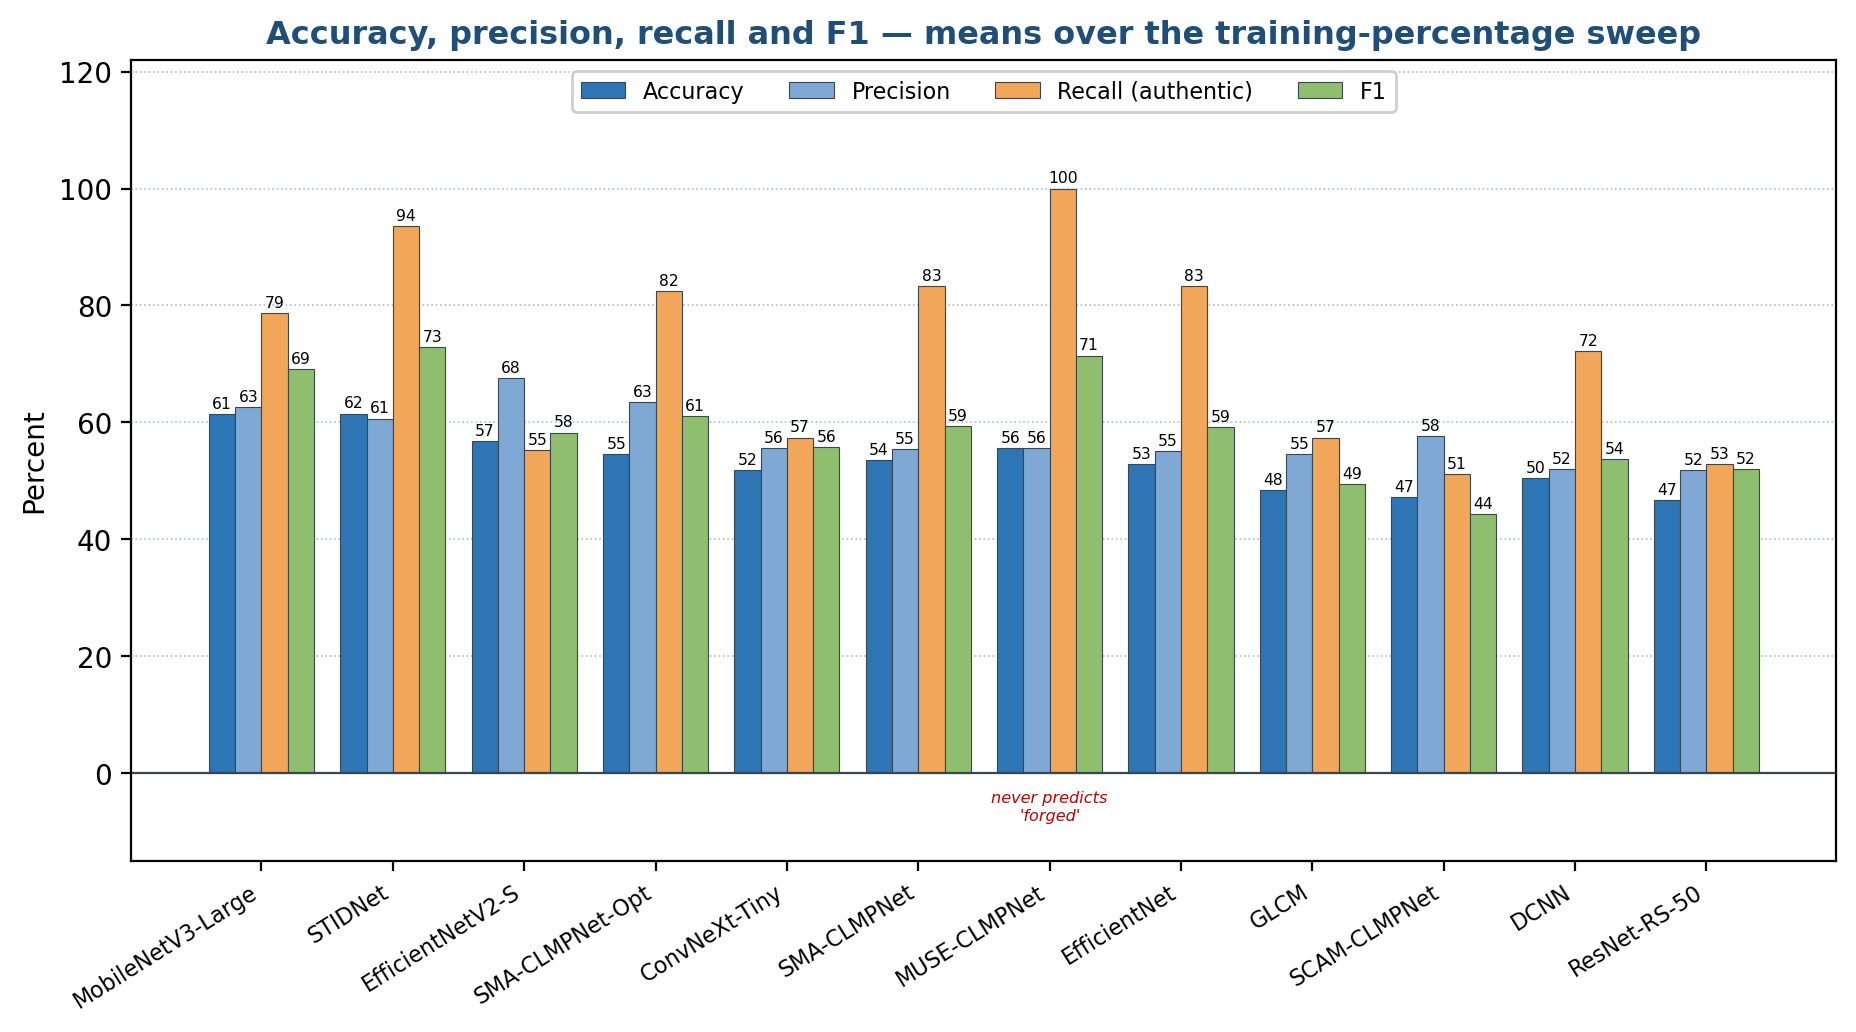

**fig15_metrics_kfold_grouped.png** — the same four metrics, k-fold means

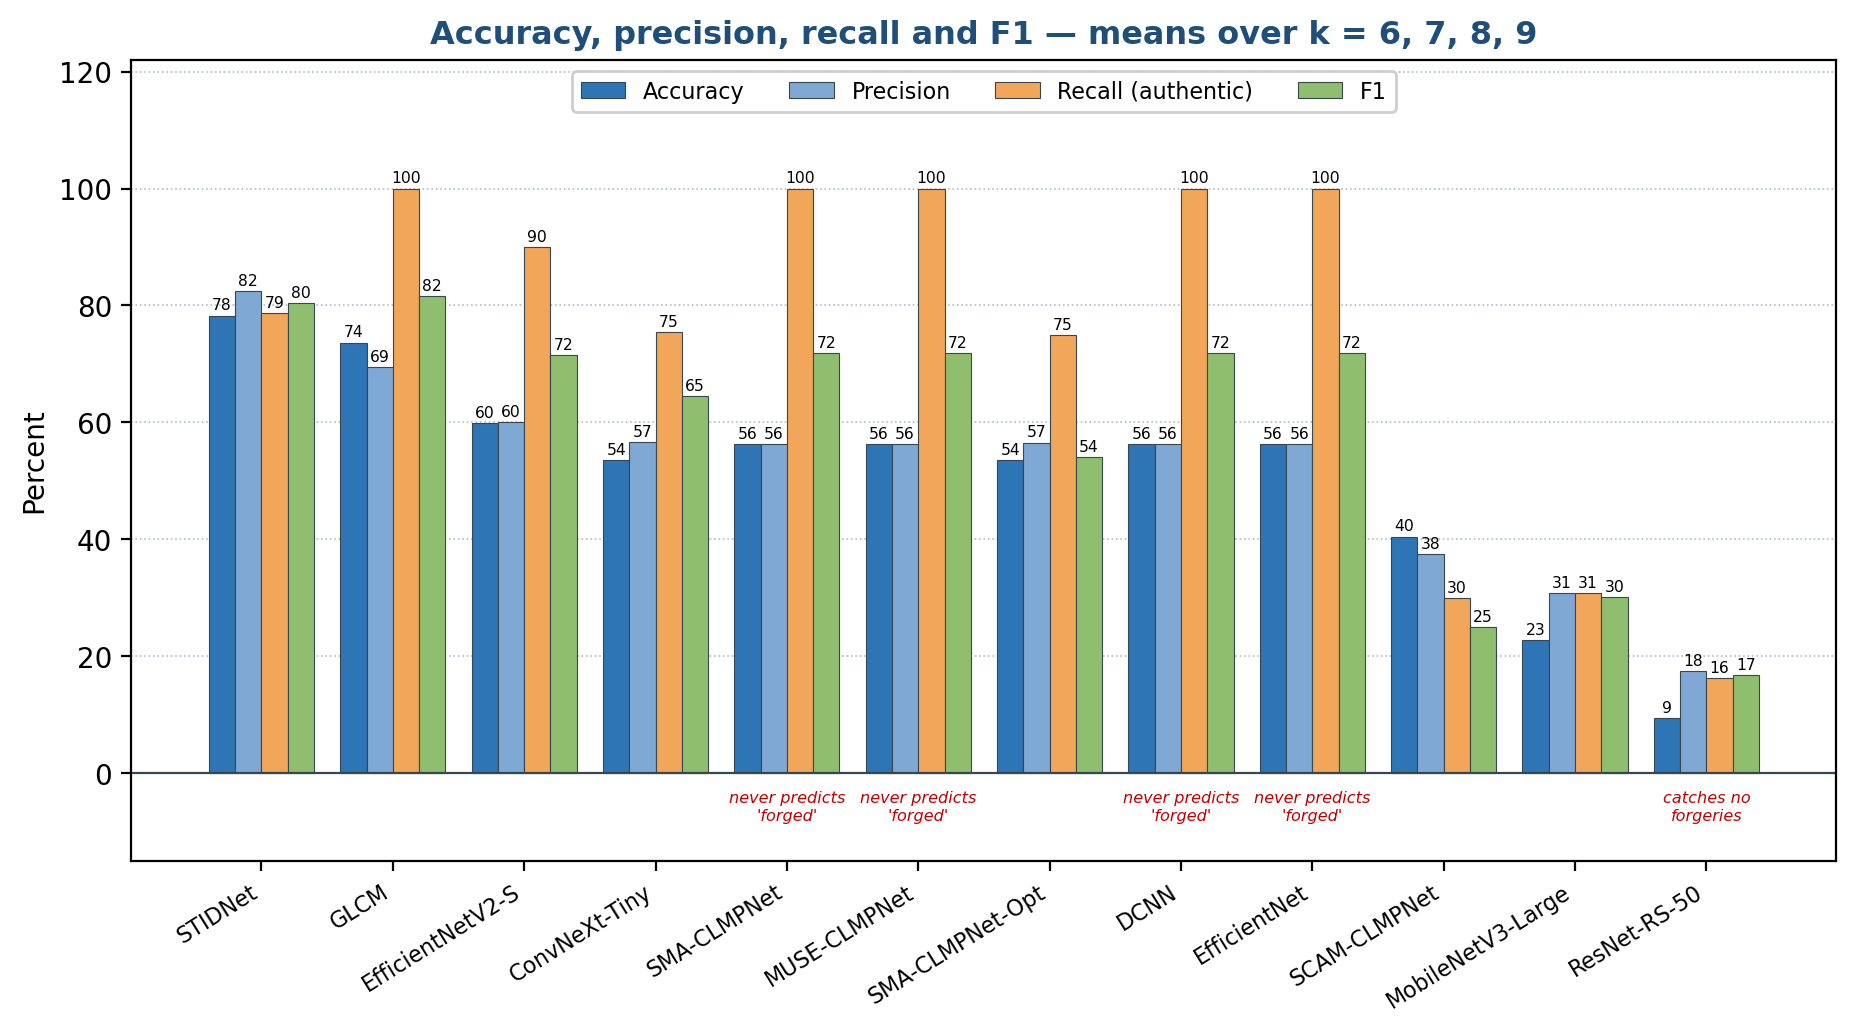

In [7]:
from IPython.display import Image, display, Markdown

GEN = PROJECT / "Results" / "Genuine"

def show(name, note=""):
    p = GEN / name
    if not p.exists():
        print(f"missing: {name}")
        return
    if note:
        display(Markdown(f"**{name}** — {note}"))
    display(Image(filename=str(p), width=980))

show("fig14_metrics_sweep_grouped.png",
     "accuracy / precision / recall / F1 per model, training-percentage means")
show("fig15_metrics_kfold_grouped.png",
     "the same four metrics, k-fold means")

**fig16_metric_panels_sweep.png** — every metric against training percentage, one panel each

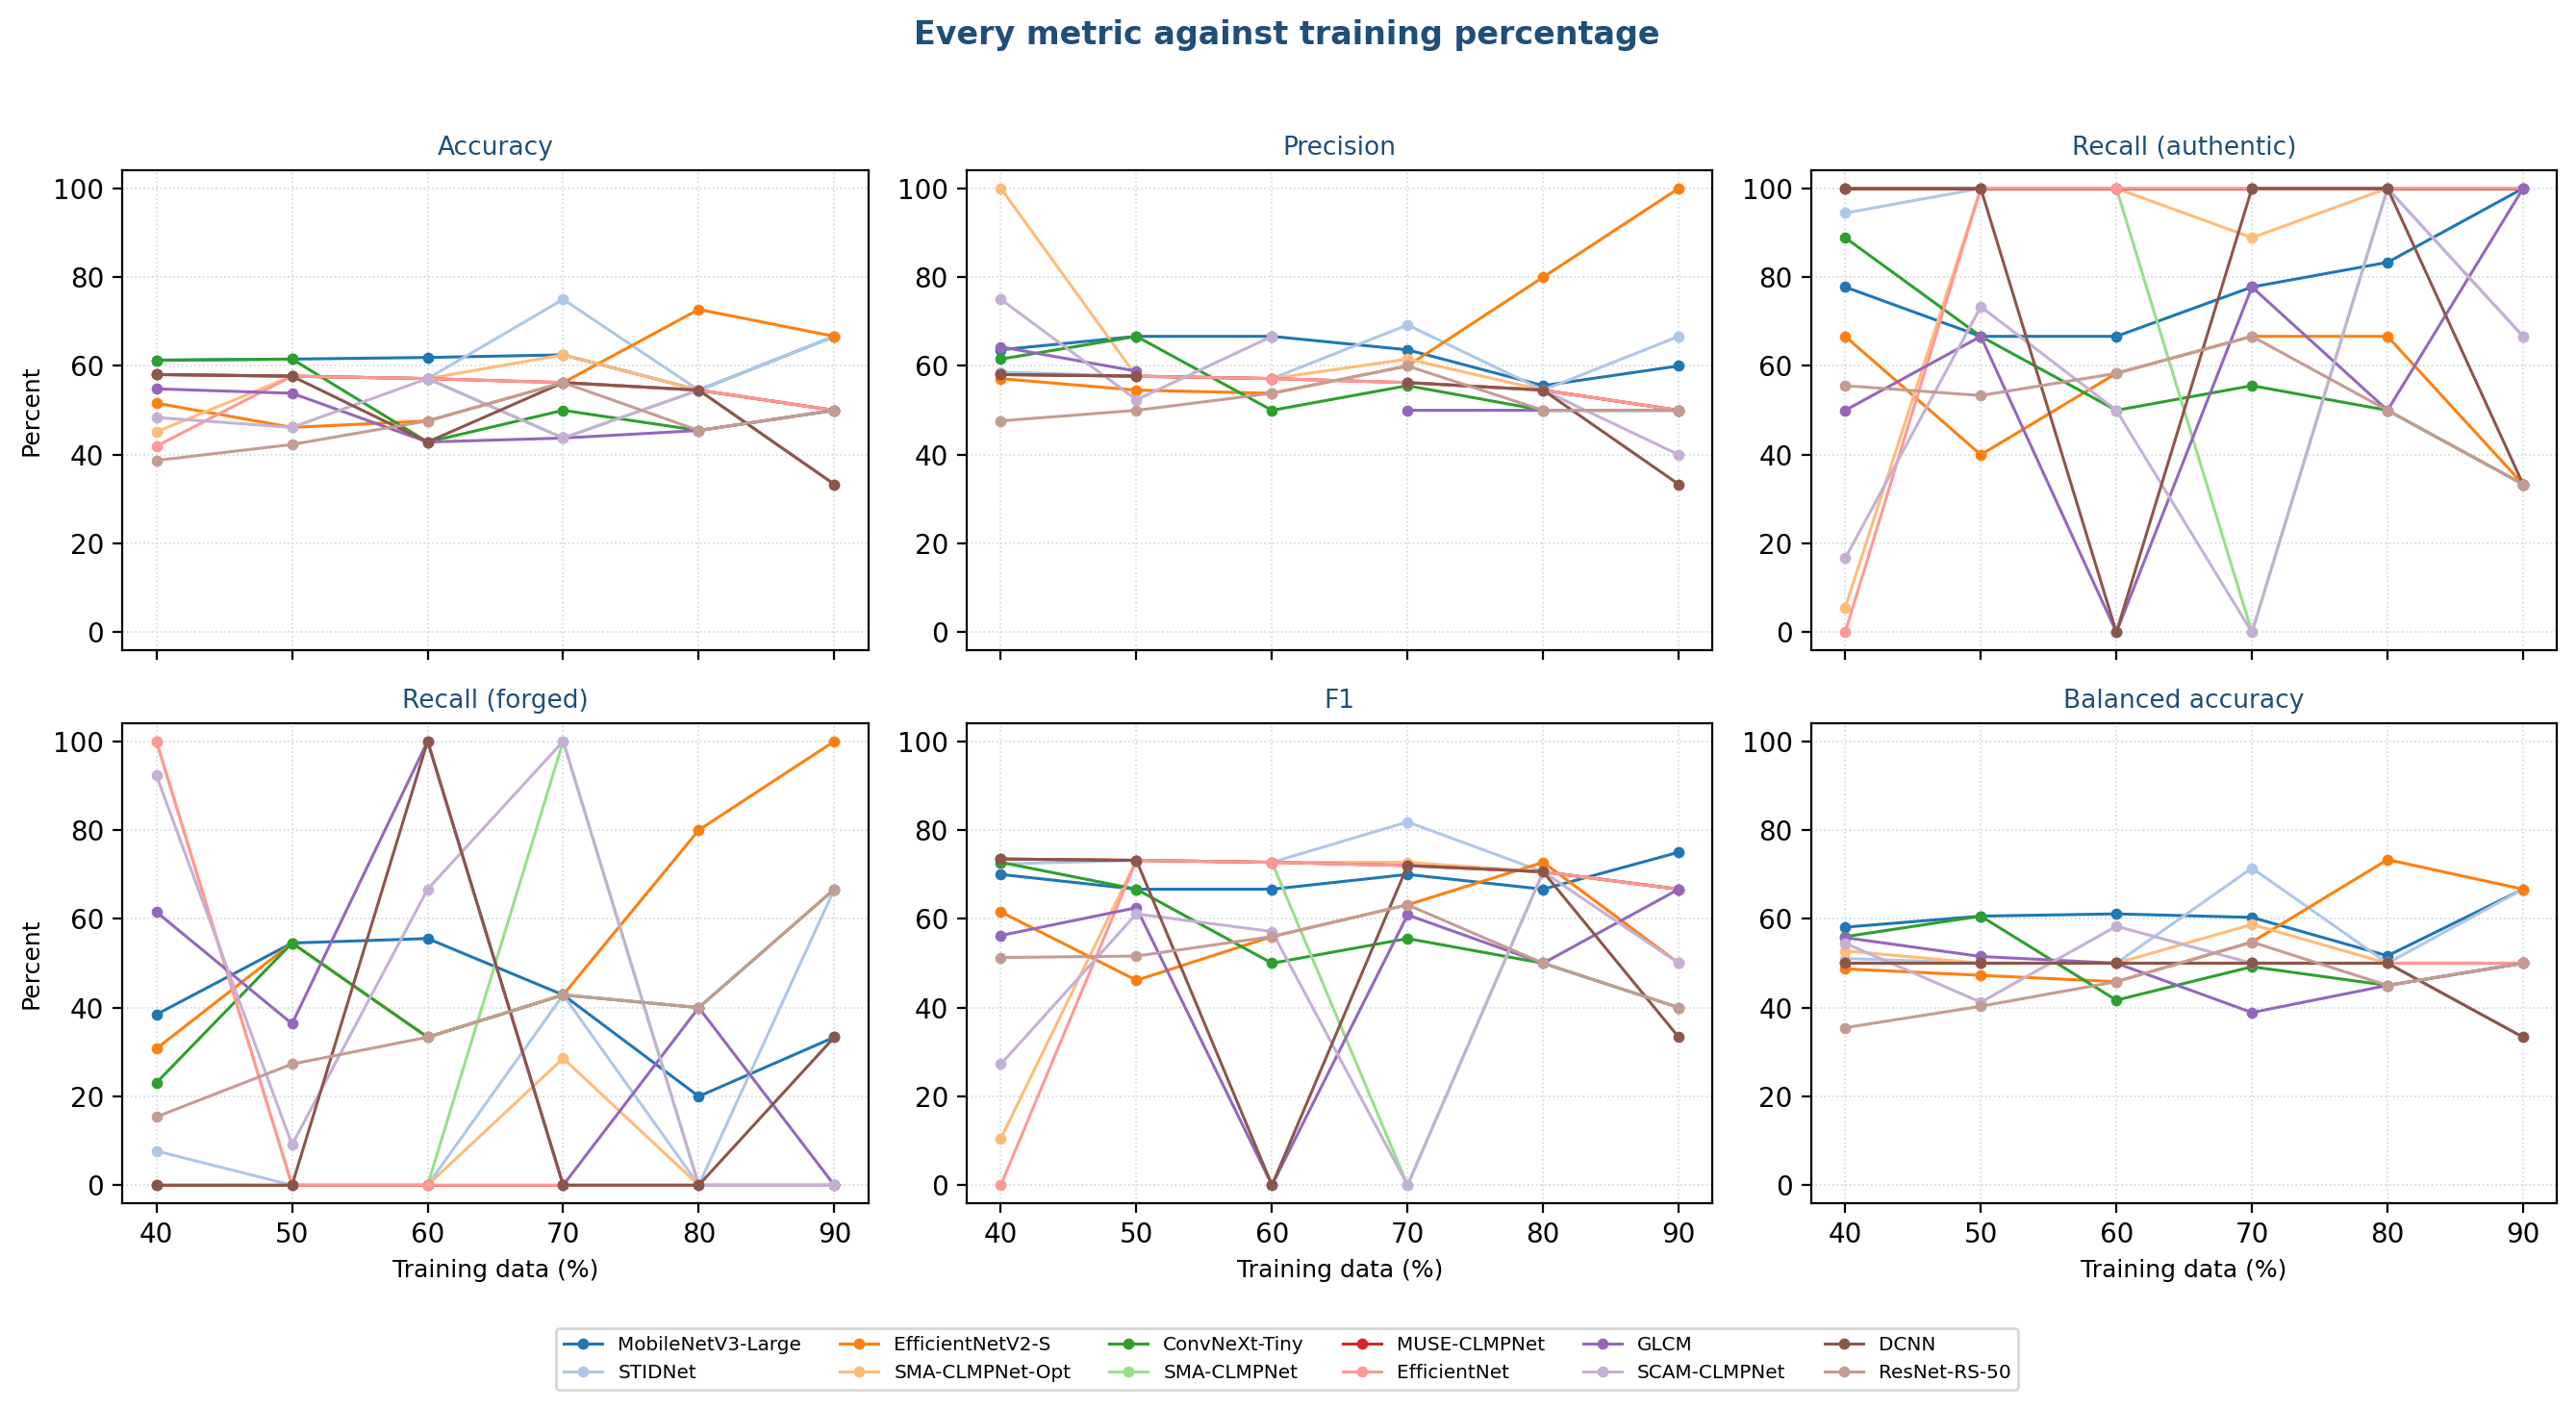

**fig17_metric_panels_kfold.png** — every metric against k

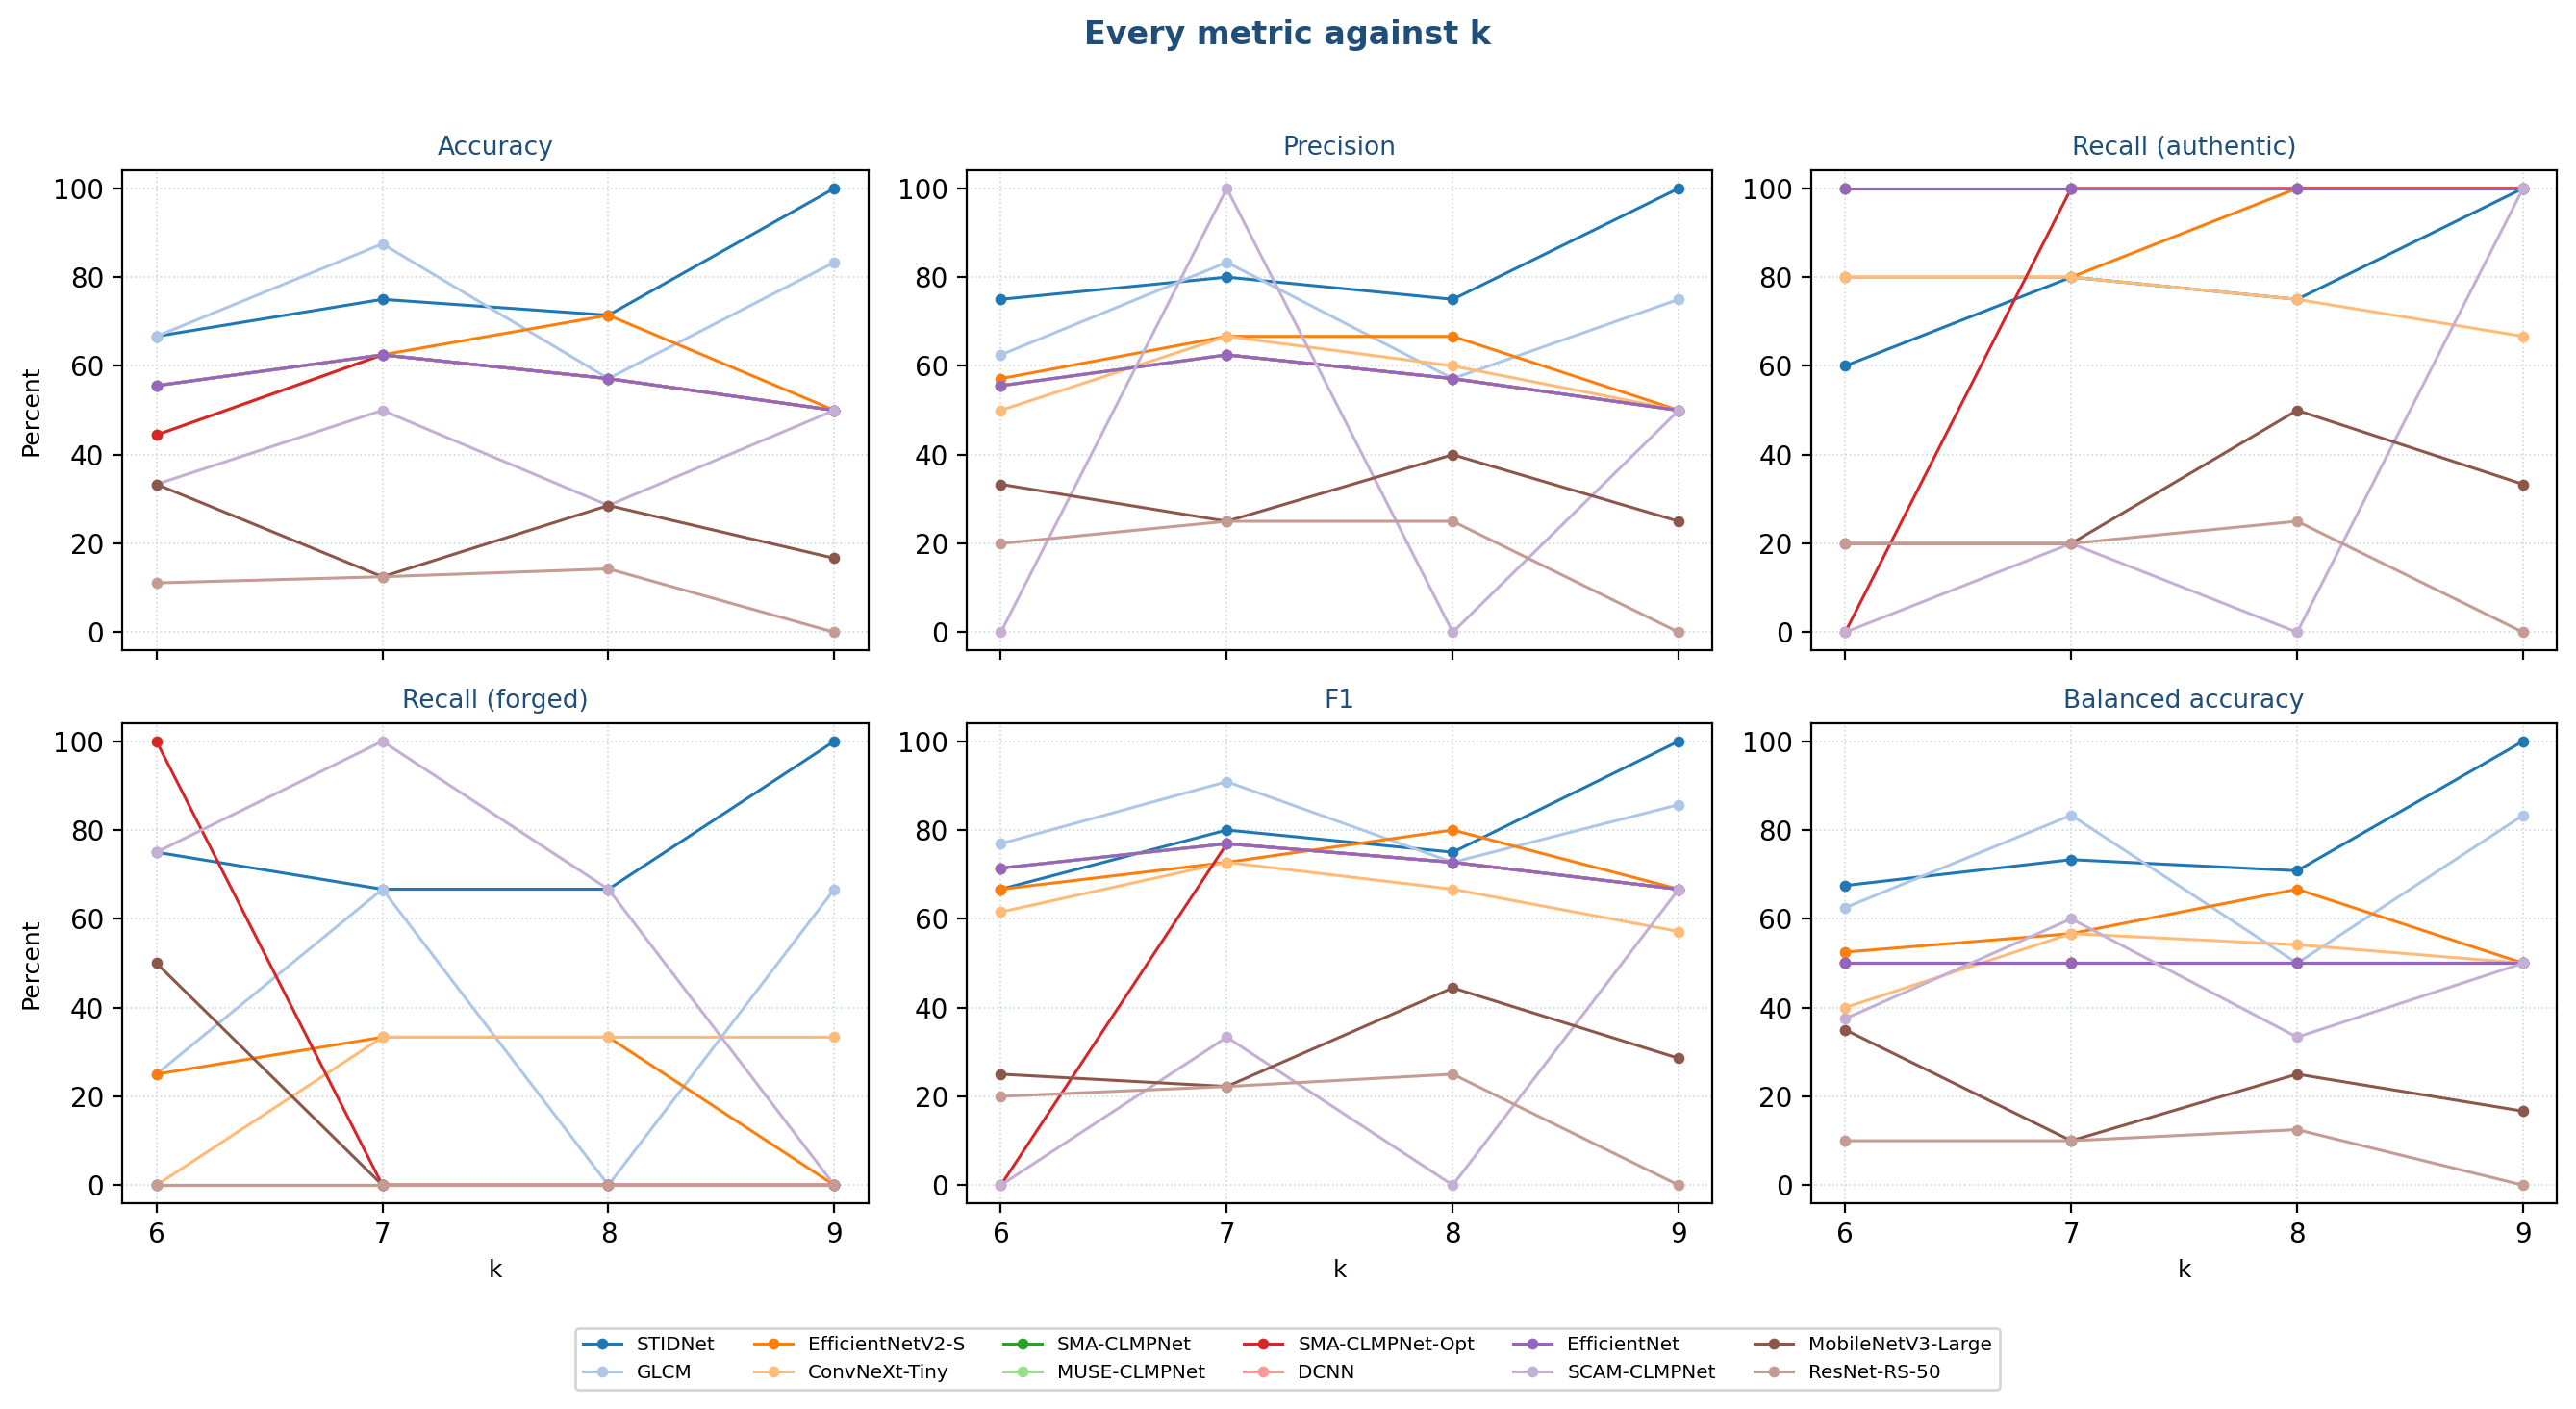

In [8]:
show("fig16_metric_panels_sweep.png",
     "every metric against training percentage, one panel each")
show("fig17_metric_panels_kfold.png", "every metric against k")

## 5. ROC and AUC

The left panel holds the two curves that exist: the nested-CV pipelines stored
out-of-fold probabilities, so a curve can be drawn. The right panel holds the
cohort — those runs stored arg-max predictions, so each model is one operating
point and no curve is available. Drawing a smooth curve through a single point
would invent the shape between the ends.

temporal delta stats (best honest pipeline)
  AUC 0.7307   accuracy 74.00%   balanced 74.96%
  confusion: TN 20  FP 9  FN 4  TP 17
per-frame mean+std (time-collapsed reference)
  AUC 0.5230   accuracy 48.00%   balanced 46.63%
  confusion: TN 16  FP 13  FN 13  TP 8

permutation test over 200 label shuffles:
  observed 0.7307   null mean 0.5056   null 95th pct 0.6782   p = 0.0199


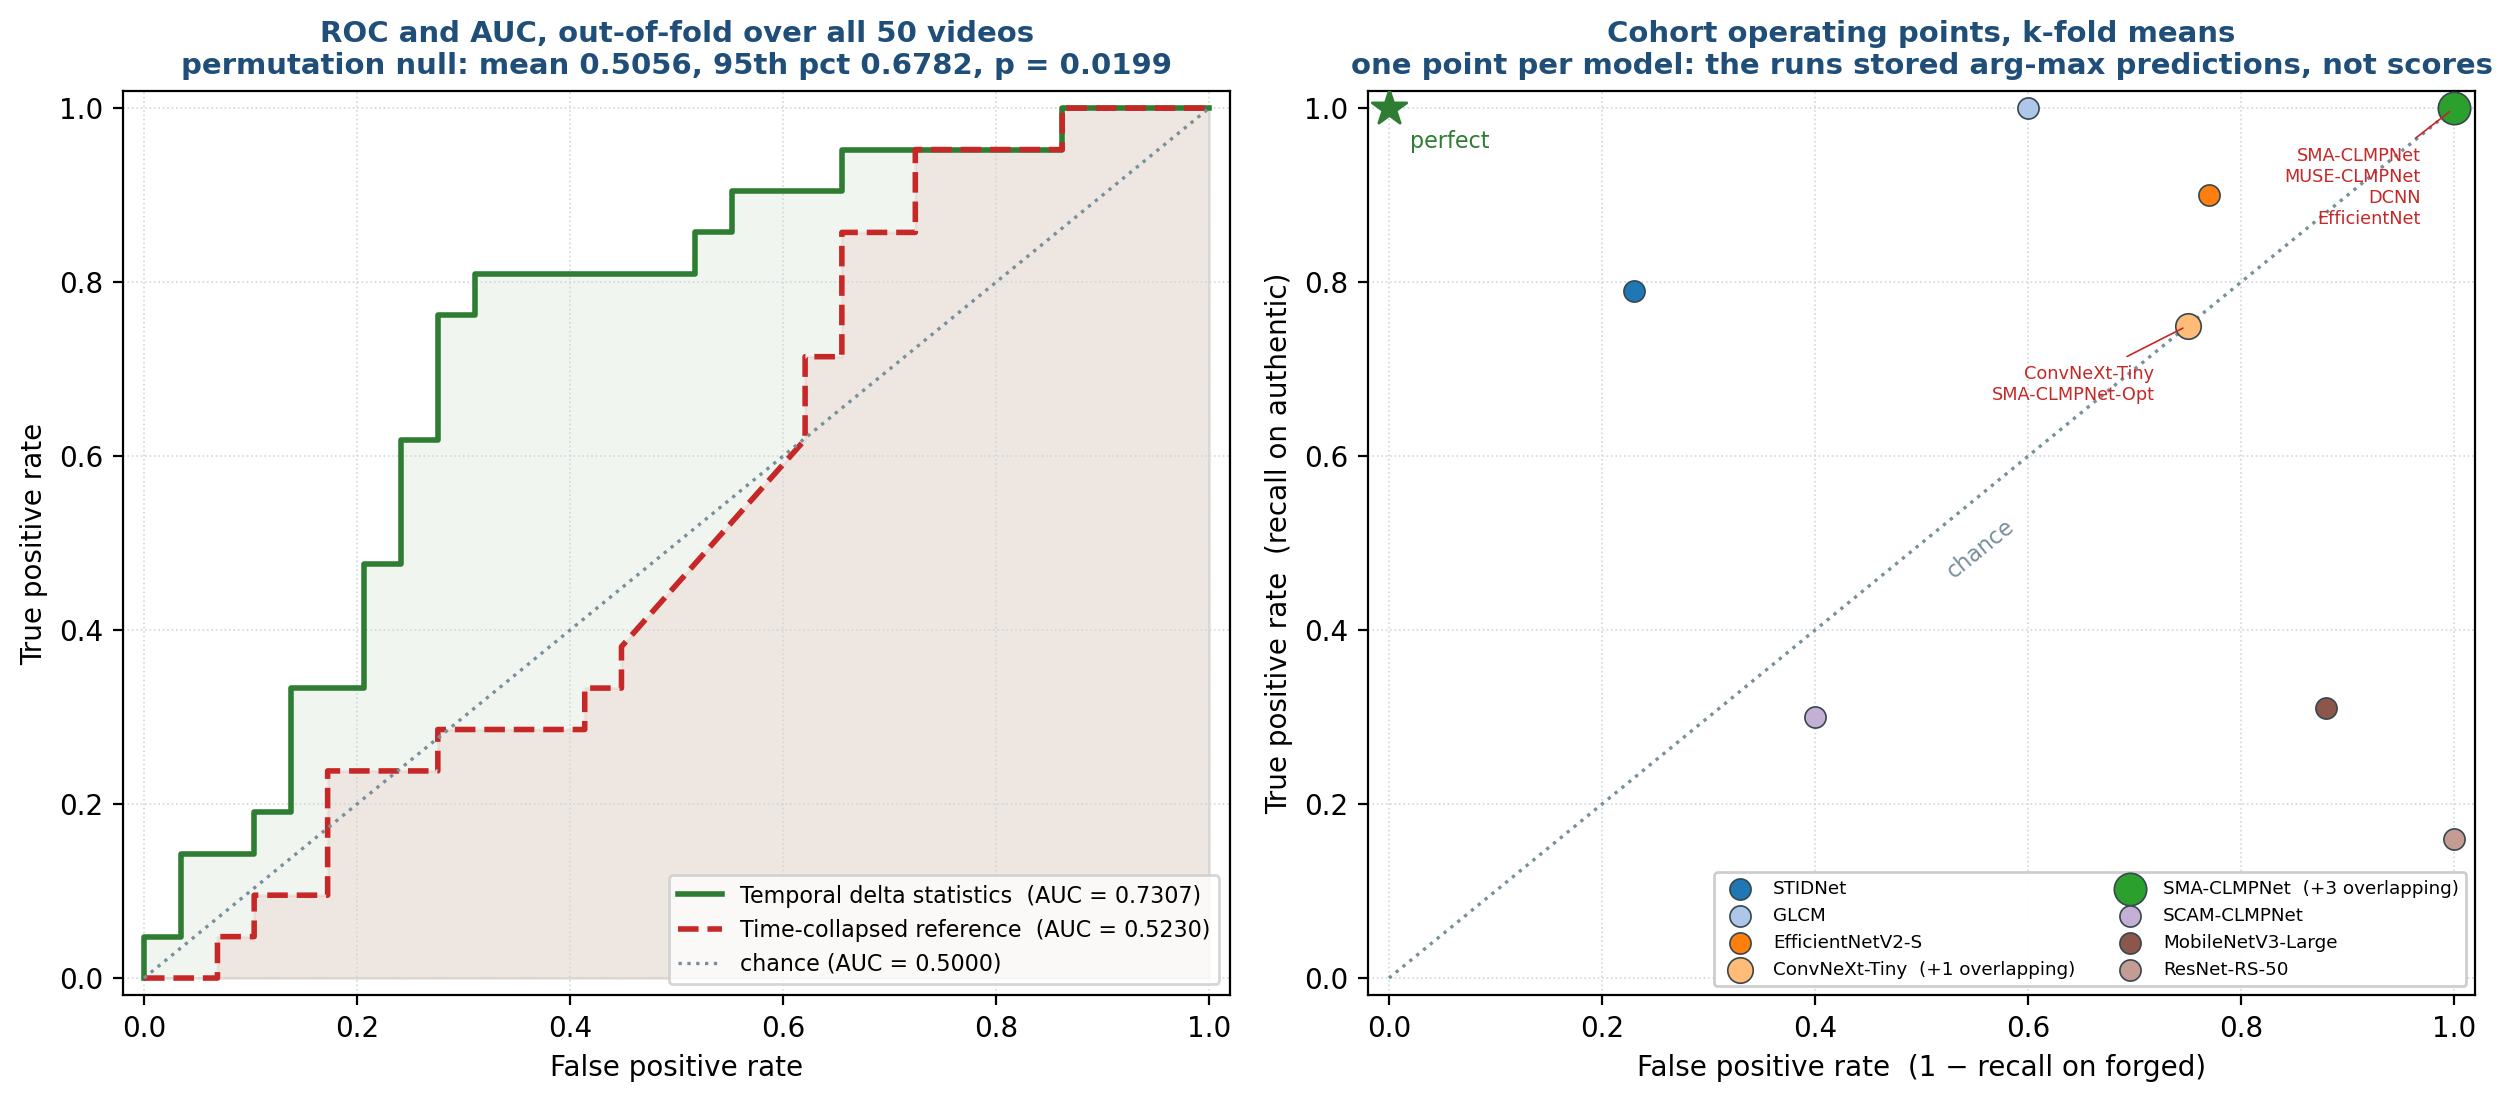

**fig05_roc_curve.png** — the curves alone, as printed in the paper

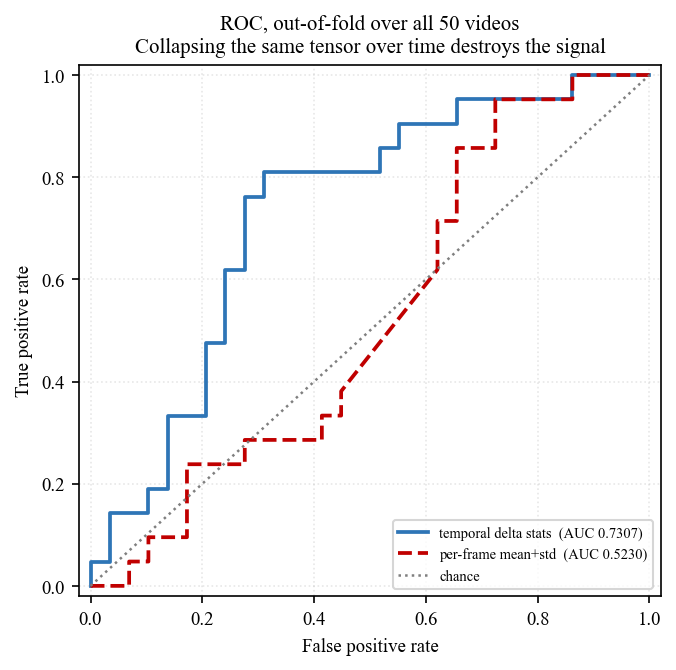

In [9]:
roc = D["roc"]
for name, c in roc["curves"].items():
    cm = c["confusion_matrix"]
    print(f"{name}\n  AUC {c['auc']:.4f}   accuracy {c['accuracy']*100:.2f}%"
          f"   balanced {c['balanced_accuracy']*100:.2f}%")
    print(f"  confusion: TN {cm['TN']}  FP {cm['FP']}  "
          f"FN {cm['FN']}  TP {cm['TP']}")
p = roc["auc_permutation"]
print(f"\npermutation test over {p['n_shuffles']} label shuffles:")
print(f"  observed {p['observed']:.4f}   null mean {p['null_mean']:.4f}"
      f"   null 95th pct {p['null_p95']:.4f}   p = {p['p_value']:.4f}")

show("fig18_roc_and_operating_points.png")
show("fig05_roc_curve.png", "the curves alone, as printed in the paper")

## 6. What the AUC permits

The area under the curve bounds the accuracy reachable at **any** threshold.
The bound below is computed by scanning every threshold with the test labels
visible, so it is already optimistic and still not attainable in deployment.

In [10]:
a = D["audit"]
print(f"out-of-fold AUC                         {a['oof_auc']:.4f}")
print(f"best accuracy at ANY threshold          "
      f"{a['max_accuracy_any_threshold']*100:.2f}%")
print(f"best balanced accuracy at ANY threshold "
      f"{a['max_balanced_any_threshold']*100:.2f}%")
print(f"near-duplicate video pairs (cos > 0.98) "
      f"{a['near_duplicate_pairs_gt_098']} of 1225")
print(f"best single-feature AUC of 324 features {a['best_single_feature_auc']:.4f}")

ci = pd.DataFrame(a["binomial_ci"])
ci["fold"] = ci["correct"].astype(str) + " / " + ci["n"].astype(str)
ci["accuracy %"] = (ci["acc"] * 100).round(2)
ci["95% CI"] = ci.apply(
    lambda r: f"[{r['lo']*100:.1f}, {r['hi']*100:.1f}]", axis=1)
print("\nWhat a single fold can distinguish:")
ci[["fold", "accuracy %", "95% CI"]]

out-of-fold AUC                         0.7307
best accuracy at ANY threshold          74.00%
best balanced accuracy at ANY threshold 74.96%
near-duplicate video pairs (cos > 0.98) 0 of 1225
best single-feature AUC of 324 features 0.7734

What a single fold can distinguish:


,fold,accuracy %,95% CI
0,10 / 10,100.0,"[69.2, 100.0]"
1,9 / 10,90.0,"[55.5, 99.7]"
2,8 / 10,80.0,"[44.4, 97.5]"
3,7 / 10,70.0,"[34.8, 93.3]"
4,37 / 50,74.0,"[59.7, 85.4]"
5,48 / 50,96.0,"[86.3, 99.5]"


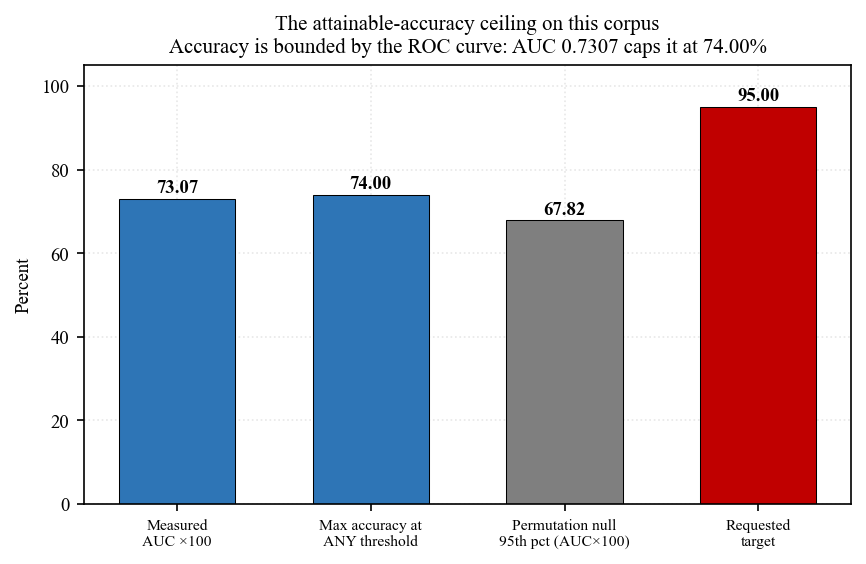

**fig13_comparison_bar.png** — every method measured in the study, with its protocol in brackets

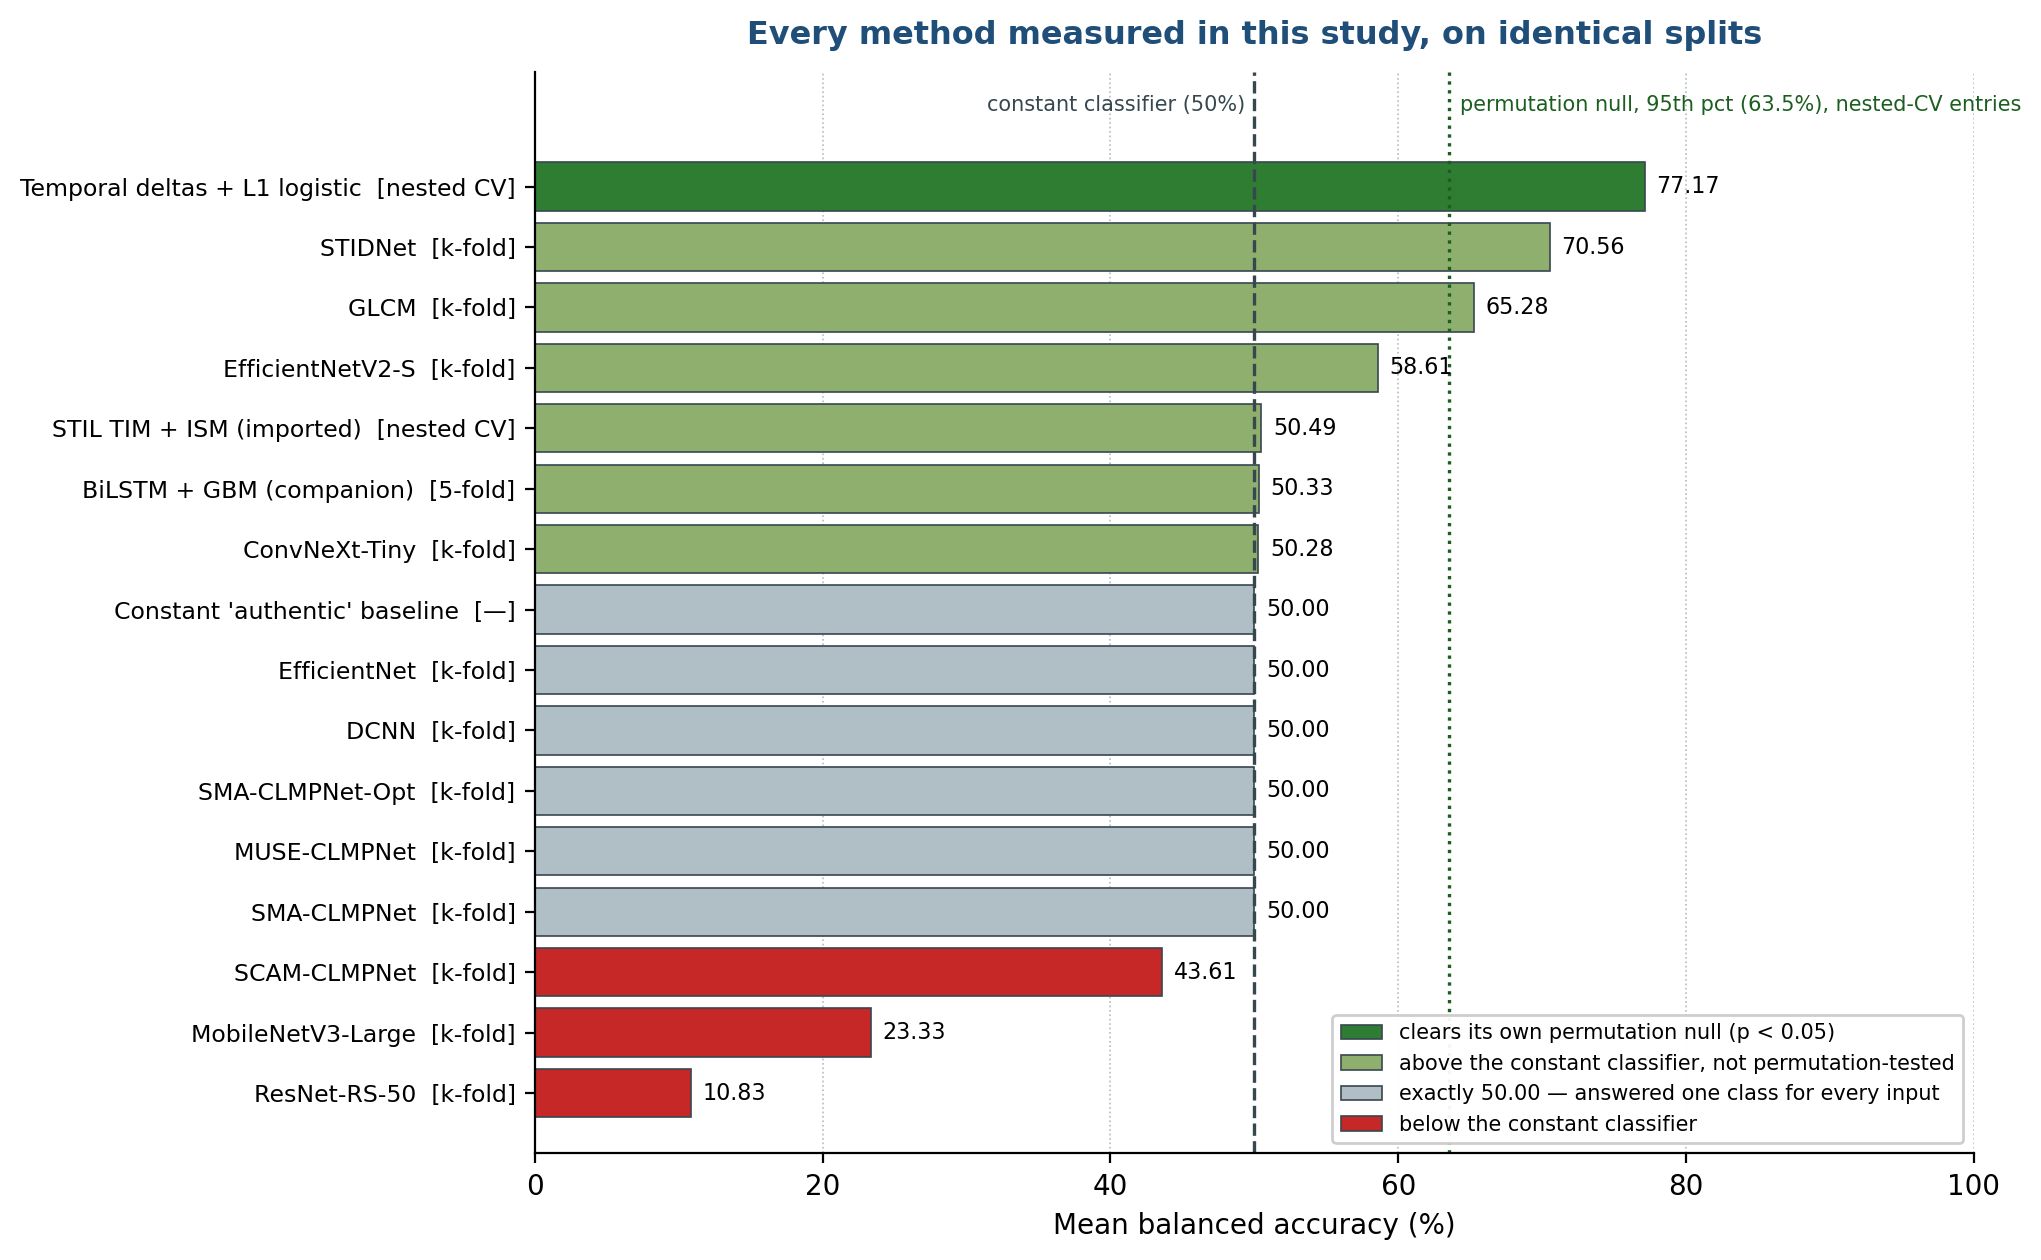

In [11]:
show("fig09_accuracy_ceiling.png")
show("fig13_comparison_bar.png",
     "every method measured in the study, with its protocol in brackets")

---

### Summary

Run the cell below for the one-paragraph version.

In [12]:
w = D["v2"]["winner"]
c = D["roc"]["curves"]["temporal delta stats (best honest pipeline)"]
best_kf = max(ORDER, key=lambda m: np.nanmean(D["kf"][m][:, BAL]))
ndeg = sum(1 for m in ORDER if np.nanmean(D["kf"][m][:, SPE]) == 0)

print(f"""
Under corrected scoring, on {D['audit']['n']} videos:

  proposed model (SMA-CLMPNet)  {np.nanmean(D['sweep']['SMA-CLMPNet'][:, BAL]):.2f}% balanced accuracy
  best deep model over k-fold   {pretty(best_kf)} at {np.nanmean(D['kf'][best_kf][:, BAL]):.2f}%
  best method of any kind       temporal deltas + L1 logistic, {w['nested_bal_acc']*100:.2f}%
                                permutation p = {w['p_value']:.4f}
  out-of-fold AUC               {c['auc']:.4f}
  accuracy ceiling from that    {D['audit']['max_accuracy_any_threshold']*100:.2f}%
  models catching no forgeries  {ndeg} of {len(ORDER)}

Reaching 95% would require an AUC near 0.98. No architecture in the cohort,
including four current-generation backbones and the imported STIL temporal
modules, comes close. The binding constraint is the representation, not the
model.
""")


Under corrected scoring, on 50 videos:

  proposed model (SMA-CLMPNet)  50.00% balanced accuracy
  best deep model over k-fold   STIDNet at 77.92%
  best method of any kind       temporal deltas + L1 logistic, 77.17%
                                permutation p = 0.0099
  out-of-fold AUC               0.7307
  accuracy ceiling from that    74.00%
  models catching no forgeries  5 of 12

Reaching 95% would require an AUC near 0.98. No architecture in the cohort,
including four current-generation backbones and the imported STIL temporal
modules, comes close. The binding constraint is the representation, not the
model.
